In [3]:
import json
import requests
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import keras_tuner as kt
import matplotlib.pyplot as plt
from collections import Counter
import keras_tuner as kt


In [4]:
# --- Load Dataset ---
url = "https://raw.githubusercontent.com/farrelrassya/teachingMLDL/main/02.%20Deep%20Learning/06.%20Week%206/Datasets/DeteksiSarkasme.json"
data = [json.loads(line) for line in requests.get(url).text.strip().split('\n')]

sentences = [item['headline'] for item in data]
labels = [item['is_sarcastic'] for item in data]


In [5]:
# --- Tokenization ---
tokenizer = keras.preprocessing.text.Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts(sentences)
word_index = tokenizer.word_index
sequences = tokenizer.texts_to_sequences(sentences)

MAX_LEN = 40
padded = keras.preprocessing.sequence.pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')
X = np.array(padded)
y = np.array(labels)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
# --- Model Building Function ---
def build_model(hp):
    model = keras.Sequential()
    model.add(layers.Embedding(input_dim=len(word_index)+1, output_dim=hp.Choice('embed_dim', [64, 128, 256]), input_length=MAX_LEN))
    model.add(layers.Bidirectional(layers.LSTM(units=hp.Int('lstm_units', 64, 256, step=64), return_sequences=False)))
    model.add(layers.Dropout(hp.Float('dropout', 0.2, 0.5, step=0.1)))
    model.add(layers.Dense(1, activation='sigmoid'))

    model.compile(optimizer=keras.optimizers.Adam(learning_rate=hp.Choice('lr', [1e-3, 3e-4, 1e-4])),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model


In [7]:
# --- Hyperparameter Tuning ---
tuner = kt.Hyperband(build_model,
                     objective='val_accuracy',
                     max_epochs=10,
                     factor=3,
                     directory='my_dir',
                     project_name='sarcasm_lstm')

early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)

tuner.search(X_train, y_train, epochs=10, validation_split=0.2, callbacks=[early_stop])

best_hps = tuner.get_best_hyperparameters(1)[0]

# --- Train Final Model ---
model = tuner.hypermodel.build(best_hps)
history = model.fit(X_train, y_train, epochs=10, validation_split=0.2, callbacks=[early_stop])

Trial 30 Complete [00h 00m 35s]
val_accuracy: 0.8535329699516296

Best val_accuracy So Far: 0.8694431185722351
Total elapsed time: 00h 13m 49s


In [9]:
# Ambil model terbaik dari tuner
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

# Buat model dengan best hyperparameters
model = build_model(best_hps)

# Latih model
history = model.fit(X_train, y_train, epochs=10, validation_split=0.2)


Epoch 1/10
535/535 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - accuracy: 0.7482 - loss: 0.4798 - val_accuracy: 0.8531 - val_loss: 0.3295
Epoch 2/10
535/535 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.9531 - loss: 0.1268 - val_accuracy: 0.8526 - val_loss: 0.3666
Epoch 3/10
535/535 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.9879 - loss: 0.0376 - val_accuracy: 0.8456 - val_loss: 0.5718
Epoch 4/10
535/535 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9947 - loss: 0.0160 - val_accuracy: 0.8451 - val_loss: 0.6302
Epoch 5/10
535/535 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.9987 - loss: 0.0050 - val_accuracy: 0.8393 - val_loss: 0.8127
Epoch 6/10
535/535 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.9988 - loss: 0.0038 - val_accuracy: 0.8374 - val_loss: 0.8187
Epoch 7/10
535/535 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9998 - loss: 0.0019 - val_accuracy: 0.8346 - val_loss: 0.8137
Epoch 8/10
535/535 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9981 - loss: 0.0066 - val

In [13]:
# --- Evaluate ---
y_probs = model.predict(X_test).ravel()
y_preds = (y_probs > 0.5).astype(int)

acc = accuracy_score(y_test, y_preds)
prec = precision_score(y_test, y_preds)
rec = recall_score(y_test, y_preds)
f1 = f1_score(y_test, y_preds)
auc = roc_auc_score(y_test, y_probs)

# Akurasi training dari epoch terakhir
train_acc = history.history['accuracy'][-1] * 100
# Akurasi testing dari epoch terakhir (val_accuracy)
test_acc = history.history['val_accuracy'][-1] * 100

print(f"\nBest Hyperparameters: {best_hps.values}")
print(f"Final Training Accuracy: {train_acc:.2f}%")
print(f"Final Testing Accuracy: {test_acc:.2f}%")
print(f"Precision: {prec:.2f}")
print(f"Recall: {rec:.2f}")
print(f"F1 Score: {f1:.2f}")
print(f"AUC: {auc:.2f}")


167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

Best Hyperparameters: {'embed_dim': 256, 'lstm_units': 256, 'dropout': 0.2, 'lr': 0.001, 'tuner/epochs': 2, 'tuner/initial_epoch': 0, 'tuner/bracket': 2, 'tuner/round': 0}
Final Training Accuracy: 99.90%
Final Testing Accuracy: 82.97%
Precision: 0.84
Recall: 0.80
F1 Score: 0.82
AUC: 0.92


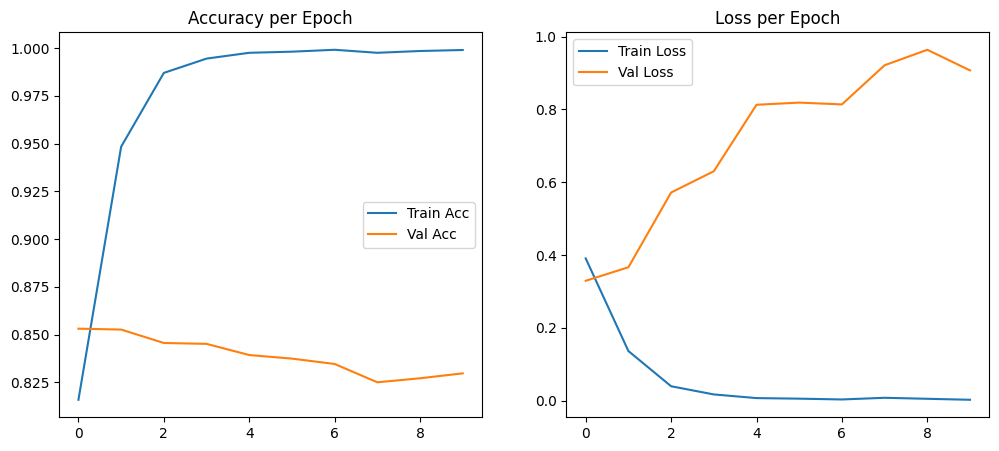

In [14]:
# --- Accuracy & Loss Plot ---
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy per Epoch')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss per Epoch')
plt.legend()
plt.show()


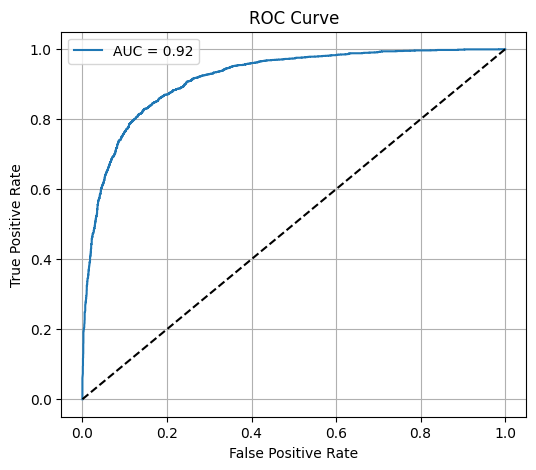

In [15]:

# --- ROC Curve ---
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_probs)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid()
plt.show()

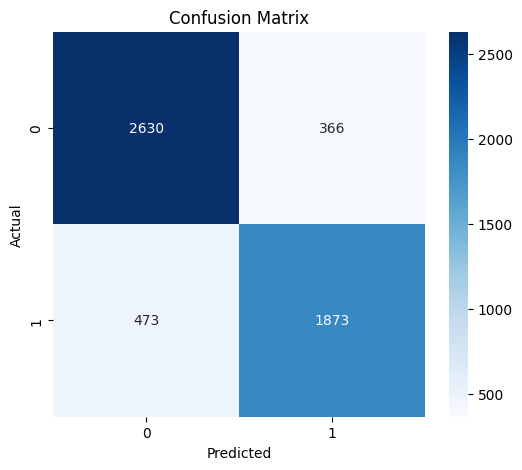

In [16]:
# --- Confusion Matrix ---
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
